## Carga de datos

In [1]:
import pandas as pd
import numpy as np

datos = pd.read_csv("../data/Datos.csv")


datos.head()


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


Datos faltantes por columna

In [2]:
datos.isna().sum()

provincia            0
zona                 0
titulo               0
PrecioActual         0
PrecioAnterior       0
metros               0
habitaciones       366
ascensor           793
localizacion      1096
planta            1225
baños                0
tags               162
descripcion         65
Enlace               0
dtype: int64

nº de filas y columnas

In [3]:
datos.shape

(11826, 14)

Nombres de las columnas

In [4]:
datos.columns

Index(['provincia', 'zona', 'titulo', 'PrecioActual', 'PrecioAnterior',
       'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta', 'baños',
       'tags', 'descripcion', 'Enlace'],
      dtype='object')

Tipos de datos y nulos

In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   provincia       11826 non-null  object 
 1   zona            11826 non-null  object 
 2   titulo          11826 non-null  object 
 3   PrecioActual    11826 non-null  int64  
 4   PrecioAnterior  11826 non-null  int64  
 5   metros          11826 non-null  int64  
 6   habitaciones    11460 non-null  float64
 7   ascensor        11033 non-null  object 
 8   localizacion    10730 non-null  object 
 9   planta          10601 non-null  object 
 10  baños           11826 non-null  int64  
 11  tags            11664 non-null  object 
 12  descripcion     11761 non-null  object 
 13  Enlace          11826 non-null  object 
dtypes: float64(1), int64(4), object(9)
memory usage: 1.3+ MB


Estadísticas (media, mediana, min...)

In [6]:
datos.describe()

,PrecioActual,PrecioAnterior,metros,habitaciones,baños
count,1.182600e+04,1.182600e+04,11826.000000,11460.000000,11826.000000
mean,1.030501e+06,7.359704e+04,153.790039,2.847731,0.394047
std,1.237718e+06,3.639753e+05,766.217750,1.432402,0.882134
min,1.200000e+04,0.000000e+00,11.000000,1.000000,0.000000
25%,2.890000e+05,0.000000e+00,68.000000,2.000000,0.000000
50%,6.200000e+05,0.000000e+00,103.000000,3.000000,0.000000
75%,1.329000e+06,0.000000e+00,160.000000,3.000000,0.000000
max,2.300000e+07,8.450000e+06,75000.000000,20.000000,7.000000


In [7]:
datos.columns = datos.columns.str.strip()

Filtrar por Madrid y renombrar variables

In [8]:
datos = datos[datos["provincia"].str.lower() == "madrid"]
datos = datos.rename(columns={
    "PrecioActual": "precio",
    "PrecioAnterior": "precio_anterior",
    "baños": "banos"
})

Quitar nulos: elimina las viviendas que no tienen precio o tamaño porque no sirven para el analisis

In [9]:
datos = datos.dropna(subset=["precio", "metros"])
datos.isna().sum()

provincia             0
zona                  0
titulo                0
precio                0
precio_anterior       0
metros                0
habitaciones        366
ascensor            793
localizacion       1096
planta             1225
banos                 0
tags                162
descripcion          65
Enlace                0
dtype: int64

Paso a variables numéricas

In [10]:
num_cols = ["precio", "metros", "habitaciones", "banos", "planta"]

for c in num_cols:
    datos[c] = (
        datos[c]
        .astype(str)
        .str.replace(r"[^\d,.\-]", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    datos[c] = pd.to_numeric(datos[c], errors="coerce")

Variables binarias

In [11]:
# precio por m2
datos["precio_m2"] = datos["precio"] / datos["metros"]

# ascensor
datos["ascensor_bin"] = datos["ascensor"].astype(str).str.upper().map({"S": 1, "N": 0})

# exterior
datos["exterior_bin"] = (
    datos["localizacion"]
    .astype(str)
    .str.upper()
    .str.contains("EXTERIOR")
    .astype(int)
)

Relleno los valores faltantes

In [12]:
# imputaciones
datos["habitaciones"] = datos["habitaciones"].fillna(datos["habitaciones"].median())
datos["planta"] = datos["planta"].fillna(datos["planta"].median())
datos["ascensor_bin"] = datos["ascensor_bin"].fillna(0)

datos["precio_habitacion"] = datos["precio"] / datos["habitaciones"].replace(0, np.nan)
datos["tamaño_habitacion"] = datos["metros"] / datos["habitaciones"].replace(0, np.nan)
datos["baños_habitacion"] = datos["banos"] / datos["habitaciones"].replace(0, np.nan)


In [13]:
datos.dtypes
datos[["precio","metros","habitaciones","banos","precio_m2"]].head()

,precio,metros,habitaciones,banos,precio_m2
0,355000,69,2.0,1,5144.927536
1,149000,91,3.0,0,1637.362637
2,195000,36,1.0,0,5416.666667
3,195000,58,1.0,0,3362.068966
4,715000,140,3.0,0,5107.142857


In [14]:
# ratios útiles
datos["precio_habitacion"] = datos["precio"] / datos["habitaciones"]
datos["tamaño_habitacion"] = datos["metros"] / datos["habitaciones"]
datos["baños_habitacion"] = datos["banos"] / datos["habitaciones"]

# logs 
datos["log_precio"] = np.log1p(datos["precio"])
datos["log_precio_m2"] = np.log1p(datos["precio_m2"])

In [15]:
datos = datos[(datos["metros"] >= 20) & (datos["metros"] <= 400)]
datos = datos[(datos["precio"] > 0) & (datos["precio_m2"] < 20000)]

In [16]:
datos.isna().sum()

provincia              0
zona                   0
titulo                 0
precio                 0
precio_anterior        0
metros                 0
habitaciones           0
ascensor             453
localizacion         755
planta                 0
banos                  0
tags                 158
descripcion           63
Enlace                 0
precio_m2              0
ascensor_bin           0
exterior_bin           0
precio_habitacion      0
tamaño_habitacion      0
baños_habitacion       0
log_precio             0
log_precio_m2          0
dtype: int64

In [17]:
datos_zone = datos.groupby("zona").agg(
    num_propiedades=("zona", "size"),
    precio_media=("precio", "mean"),
    precio_m2_media=("precio_m2", "mean"),
    precio_m2_mediana=("precio_m2", "median"),
    precio_std=("precio", "std"),
    metros_media=("metros", "mean"),
    metros_mediana=("metros", "median"),
    habitaciones_media=("habitaciones", "mean"),
    banos_media=("banos", "mean"),
    planta_media=("planta", "mean"),
    ascensor_ratio=("ascensor_bin", "mean"),
    exterior_ratio=("exterior_bin", "mean"),
).reset_index()

## Dataset para recomendacion

Desde este punto el notebook deja de centrarse en comparar modelos predictivos aislados y pasa a un enfoque de apoyo a la decision.

La unidad de recomendacion es la zona (`zone_key`) y el problema se formula como un trade-off entre precio, accesibilidad y caracteristicas residenciales. Por tanto, el objetivo no es "predecir mejor" sino identificar zonas razonables segun restricciones y preferencias del usuario.


In [18]:
def normalizar_zona(z):
    return str(z).lower().strip().replace(" ", "-")

datos_zone = datos_zone.copy()
datos_zone["zone_key"] = datos_zone["zona"].apply(normalizar_zona)

datos_ml = datos_zone.drop(columns=["zona"]).copy()
datos_ml.to_csv("../data/datos_zone_ml.csv", index=False)

datos_ml.head()

,num_propiedades,precio_media,precio_m2_media,precio_m2_mediana,precio_std,metros_media,metros_mediana,habitaciones_media,banos_media,planta_media,ascensor_ratio,exterior_ratio,zone_key
0,378,4.921745e+05,5671.370191,5438.185654,2.702781e+05,87.592593,80.5,2.333333,0.293651,2.978836,0.812169,0.703704,arganzuela
1,96,5.510072e+05,4287.686217,4276.099600,3.348023e+05,137.791667,98.0,2.947917,0.489583,3.020833,0.572917,0.718750,barajas
2,1925,1.733741e+06,10734.636314,10576.719577,1.122443e+06,157.181818,137.0,2.798442,0.526234,3.196883,0.938182,0.773506,barrio-de-salamanca
3,565,2.702966e+05,3204.743796,3125.000000,1.472186e+05,85.053097,75.0,2.529204,0.270796,2.923894,0.493805,0.854867,carabanchel
4,1857,8.314256e+05,7491.033396,7200.000000,6.468126e+05,106.710285,98.0,2.501885,0.372644,2.801831,0.680668,0.747442,centro


In [19]:
datos_ml.isna().sum()

num_propiedades       0
precio_media          0
precio_m2_media       0
precio_m2_mediana     0
precio_std            0
metros_media          0
metros_mediana        0
habitaciones_media    0
banos_media           0
planta_media          0
ascensor_ratio        0
exterior_ratio        0
zone_key              0
dtype: int64

## Integracion de accesibilidad

Se incorpora una variable de coste temporal por zona para que la recomendacion no dependa solo del presupuesto.

Importante: el archivo `accessibility_template_filled.csv` usa tiempos de OpenRouteService con perfil `driving-car` como *proxy* de accesibilidad, no tiempos reales GTFS o EDM. Esto permite demostrar el flujo metodologico completo, pero la memoria debe dejar clara esta limitacion y plantear como mejora futura la sustitucion por tiempos observados o de transporte publico real.


In [20]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

current_dir = Path.cwd().resolve()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.recommendation_pipeline import (
    DEFAULT_PROFILES,
    UserProfile,
    attach_accessibility_features,
    build_accessibility_template,
    compute_pareto_front,
    hybrid_knn_recommendation,
    rank_zones_for_profile,
)


In [21]:
acc_filled_path = project_root / "data" / "accessibility_template_filled.csv"
acc_template_path = project_root / "data" / "accessibility_template.csv"

if acc_filled_path.exists():
    accessibility_path = acc_filled_path
elif acc_template_path.exists():
    accessibility_path = acc_template_path
else:
    accessibility_path = acc_template_path
    accesibilidad = build_accessibility_template(
        zone_keys=datos_ml["zone_key"],
        destinations=["sol", "cuatro_caminos", "las_tablas"],
    )
    accesibilidad.to_csv(accessibility_path, index=False)

if "accesibilidad" not in globals():
    accesibilidad = pd.read_csv(accessibility_path)

print(f"Dataset de accesibilidad usado: {accessibility_path.name}")
accesibilidad.head()


Dataset de accesibilidad usado: accessibility_template_filled.csv


,zone_key,destino,modo,tiempo_transporte_min,fuente
0,arganzuela,alcala_castellana,transporte_publico,14.03,openrouteservice:driving-car_proxy:2026-04-25T...
1,arganzuela,atocha,transporte_publico,2.79,openrouteservice:driving-car_proxy:2026-04-25T...
2,arganzuela,campo_naciones,transporte_publico,23.91,openrouteservice:driving-car_proxy:2026-04-25T...
3,arganzuela,chamartin,transporte_publico,15.64,openrouteservice:driving-car_proxy:2026-04-25T...
4,arganzuela,cuatro_caminos,transporte_publico,14.05,openrouteservice:driving-car_proxy:2026-04-25T...


In [22]:
# Relleno de respaldo para garantizar ejecucion incluso si faltan tiempos.
# Si hay datos ya calculados en accessibility_template_filled.csv, este bloque solo actua sobre nulos residuales.
fallback_base_times = {
    "arganzuela": 18, "barajas": 35, "barrio-de-salamanca": 16, "carabanchel": 28,
    "centro": 5, "chamartin": 19, "chamberi": 14, "ciudad-lineal": 23,
    "fuencarral": 30, "hortaleza": 27, "latina": 24, "moncloa": 17,
    "moratalaz": 26, "puente-de-vallecas": 25, "retiro": 15, "san-blas": 29,
    "tetuan": 18, "usera": 22, "vicalvaro": 33, "villa-de-vallecas": 38, "villaverde": 31,
}
destination_adjustment = {
    "sol": 0, "cuatro_caminos": 6, "las_tablas": 12, "atocha": 4, "plaza_espana": 3,
    "chamartin": 10, "retiro": 4, "tribunal": 3, "serrano": 5, "campo_naciones": 14,
    "alcala_castellana": 8, "moncloa_universidad": 7, "ferraz": 5,
}

default_zone_time = float(pd.Series(fallback_base_times).median())
default_destination_adjustment = 8.0

missing_mask = accesibilidad["tiempo_transporte_min"].isna()
if missing_mask.any():
    zone_component = accesibilidad.loc[missing_mask, "zone_key"].map(fallback_base_times).fillna(default_zone_time)
    dest_component = accesibilidad.loc[missing_mask, "destino"].map(destination_adjustment).fillna(default_destination_adjustment)
    accesibilidad.loc[missing_mask, "tiempo_transporte_min"] = zone_component.to_numpy() + dest_component.to_numpy()
    accesibilidad.loc[missing_mask, "fuente"] = "fallback_notebook"

accesibilidad["es_proxy_ors"] = accesibilidad["fuente"].fillna("").str.contains("driving-car_proxy")
accesibilidad["es_fallback"] = accesibilidad["fuente"].fillna("").str.contains("fallback")

accesibilidad["tiempo_transporte_min"].isna().sum()


np.int64(0)

In [23]:
datos_recomendacion = attach_accessibility_features(datos_ml, accesibilidad)
columnas_tiempo = sorted([c for c in datos_recomendacion.columns if c.startswith("tt_")])
destinos_disponibles = [c.replace("tt_", "") for c in columnas_tiempo]

datos_recomendacion[["zone_key", "precio_media", *columnas_tiempo[:5]]].head()


,zone_key,precio_media,tt_alcala_castellana,tt_atocha,tt_campo_naciones,tt_chamartin,tt_cuatro_caminos
0,arganzuela,4.921745e+05,14.03,2.79,23.91,15.64,14.05
1,barajas,5.510072e+05,17.55,21.23,12.36,15.64,18.54
2,barrio-de-salamanca,1.733741e+06,7.12,10.43,20.94,7.96,6.74
3,carabanchel,2.702966e+05,21.65,13.28,28.22,20.01,20.39
4,centro,8.314256e+05,17.42,9.96,28.75,19.69,15.79


## Diagnostico de la accesibilidad

Antes de recomendar conviene revisar la cobertura del dato temporal y su procedencia. Este paso deja claro si trabajamos con tiempos completos, si hay rellenos artificiales y cuantas zonas quedan cubiertas por destino.


In [24]:
resumen_fuentes = (
    accesibilidad.assign(tipo_fuente=lambda df: df["fuente"].fillna("desconocida"))
    .groupby("tipo_fuente", as_index=False)
    .agg(
        filas=("zone_key", "size"),
        destinos=("destino", "nunique"),
        zonas=("zone_key", "nunique"),
        tiempo_medio=("tiempo_transporte_min", "mean"),
    )
    .sort_values("filas", ascending=False)
)

resumen_destinos = (
    accesibilidad.groupby("destino", as_index=False)
    .agg(
        zonas_cubiertas=("zone_key", "nunique"),
        tiempo_medio=("tiempo_transporte_min", "mean"),
        tiempo_mediana=("tiempo_transporte_min", "median"),
        tiempo_min=("tiempo_transporte_min", "min"),
        tiempo_max=("tiempo_transporte_min", "max"),
    )
    .sort_values("tiempo_medio")
)

display(resumen_fuentes)
display(resumen_destinos)

print(f"Zonas agregadas: {datos_ml['zone_key'].nunique()}")
print(f"Destinos disponibles: {', '.join(destinos_disponibles)}")
print(f"Filas marcadas como proxy ORS: {int(accesibilidad['es_proxy_ors'].sum())}/{len(accesibilidad)}")
print(f"Filas con fallback: {int(accesibilidad['es_fallback'].sum())}/{len(accesibilidad)}")


,tipo_fuente,filas,destinos,zonas,tiempo_medio
1,openrouteservice:driving-car_proxy:2026-04-25T...,271,13,21,15.120406
0,fallback_haversine:driving-car:KeyError:2026-0...,2,2,2,1.000000


,destino,zonas_cubiertas,tiempo_medio,tiempo_mediana,tiempo_min,tiempo_max
10,serrano,21,11.769048,11.35,1.86,19.45
9,retiro,21,13.300000,14.26,1.00,19.57
3,chamartin,21,13.322857,12.78,2.71,20.64
1,atocha,21,13.370476,14.35,2.79,21.23
12,tribunal,21,13.440000,14.37,1.86,24.16
0,alcala_castellana,21,13.465714,14.03,2.84,22.28
5,ferraz,21,14.340000,13.31,5.27,25.81
8,plaza_espana,21,14.459048,14.29,6.36,24.77
4,cuatro_caminos,21,14.495714,15.71,5.04,24.85
11,sol,21,16.135238,15.83,1.00,27.23


Zonas agregadas: 21
Destinos disponibles: alcala_castellana, atocha, campo_naciones, chamartin, cuatro_caminos, ferraz, las_tablas, moncloa_universidad, plaza_espana, retiro, serrano, sol, tribunal
Filas marcadas como proxy ORS: 271/273
Filas con fallback: 2/273


## Frontera de Pareto

La frontera de Pareto es mas coherente con el objetivo del TFG que una regresion aislada: identifica zonas no dominadas donde no puede mejorarse el tiempo sin empeorar el precio, ni abaratarse el precio sin empeorar el acceso.

Primero se visualiza la frontera respecto a Sol y despues se comprueba la robustez del resultado para otro polo de actividad como Las Tablas.


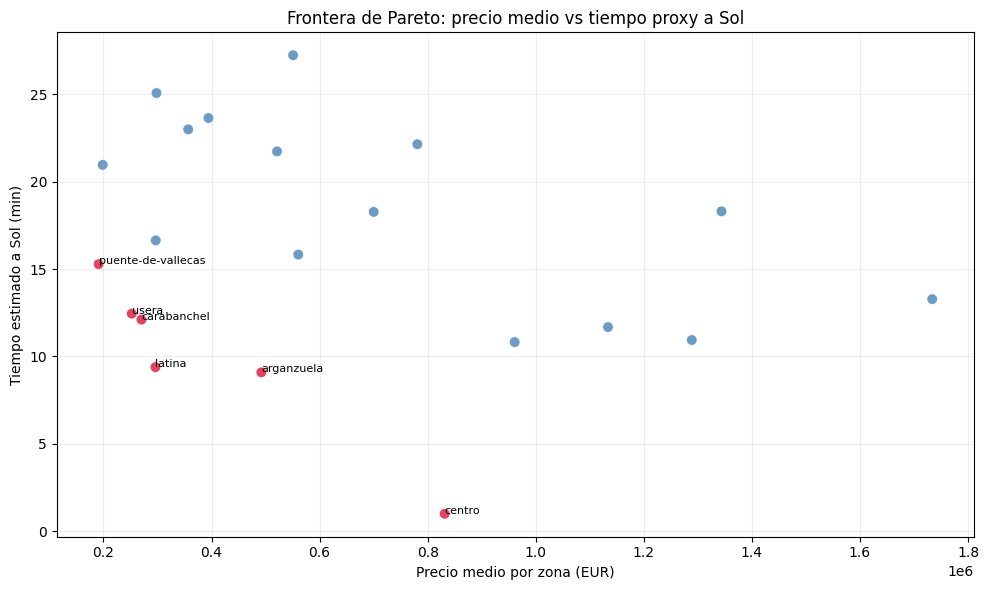

,zone_key,precio_media,tt_sol,tt_las_tablas,metros_media,pareto_sol,pareto_las_tablas,n_pareto
13,puente-de-vallecas,1.909634e+05,15.28,18.45,70.063462,True,True,2
4,centro,8.314256e+05,1.00,24.98,106.710285,True,False,1
0,arganzuela,4.921745e+05,9.09,21.54,87.592593,True,False,1
10,latina,2.961525e+05,9.39,25.14,87.587879,True,False,1
3,carabanchel,2.702966e+05,12.11,25.91,85.053097,True,False,1
17,usera,2.523420e+05,12.45,18.69,82.155629,True,False,1
12,moratalaz,2.967722e+05,16.64,17.43,84.329897,False,True,1
8,fuencarral,7.000802e+05,18.27,9.27,130.209581,False,True,1
7,ciudad-lineal,5.212215e+05,21.73,15.94,104.145558,False,True,1
11,moncloa,9.609205e+05,10.82,17.48,162.482759,False,False,0


In [25]:
pareto_sol = compute_pareto_front(datos_recomendacion, price_col="precio_media", time_col="tt_sol")
pareto_las_tablas = compute_pareto_front(datos_recomendacion, price_col="precio_media", time_col="tt_las_tablas")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    pareto_sol["precio_media"],
    pareto_sol["tt_sol"],
    c=pareto_sol["pareto_optima"].map({True: "crimson", False: "steelblue"}),
    alpha=0.8,
    s=60,
    edgecolor="white",
    linewidth=0.7,
)
for _, row in pareto_sol[pareto_sol["pareto_optima"]].iterrows():
    ax.annotate(row["zone_key"], (row["precio_media"], row["tt_sol"]), fontsize=8)

ax.set_title("Frontera de Pareto: precio medio vs tiempo proxy a Sol")
ax.set_xlabel("Precio medio por zona (EUR)")
ax.set_ylabel("Tiempo estimado a Sol (min)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

resumen_pareto = (
    datos_recomendacion[["zone_key", "precio_media", "metros_media", "tt_sol", "tt_las_tablas"]]
    .merge(
        pareto_sol[["zone_key", "pareto_optima"]].rename(columns={"pareto_optima": "pareto_sol"}),
        on="zone_key",
        how="left",
    )
    .merge(
        pareto_las_tablas[["zone_key", "pareto_optima"]].rename(columns={"pareto_optima": "pareto_las_tablas"}),
        on="zone_key",
        how="left",
    )
)
resumen_pareto["n_pareto"] = resumen_pareto[["pareto_sol", "pareto_las_tablas"]].fillna(False).sum(axis=1)

resumen_pareto.sort_values(
    ["n_pareto", "tt_sol", "precio_media"],
    ascending=[False, True, True],
)[["zone_key", "precio_media", "tt_sol", "tt_las_tablas", "metros_media", "pareto_sol", "pareto_las_tablas", "n_pareto"]]


## Validacion con perfiles de usuario

Se definen tres personas para comprobar que el sistema no devuelve siempre la misma solucion:

- estudiante con presupuesto bajo y destino principal en Sol
- profesional con mayor presupuesto y empleo en Las Tablas
- familia que busca equilibrio entre espacio y accesibilidad

La idea no es acertar una etiqueta, sino mostrar que la utilidad cambia de forma interpretable cuando cambian presupuesto, tamaño deseado y tiempo objetivo.


In [26]:
perfil_estudiante = DEFAULT_PROFILES["estudiante_centro"]
perfil_profesional = DEFAULT_PROFILES["profesional_periferia"]
perfil_familia = DEFAULT_PROFILES["familia_equilibrada"]

def resumir_perfil(nombre_perfil, profile, time_col, top_n=5):
    top = rank_zones_for_profile(datos_recomendacion, profile, time_col=time_col, top_n=top_n).copy()
    top["perfil"] = nombre_perfil
    top["destino"] = time_col.replace("tt_", "")
    top["ranking"] = range(1, len(top) + 1)
    return top[[
        "perfil", "ranking", "zone_key", "destino", "utility_score",
        "precio_media", time_col, "metros_media", "within_budget", "within_commute"
    ]].rename(columns={time_col: "tiempo_destino_min"})

comparativa_perfiles = pd.concat(
    [
        resumir_perfil("estudiante", perfil_estudiante, "tt_sol"),
        resumir_perfil("profesional", perfil_profesional, "tt_las_tablas"),
        resumir_perfil("familia", perfil_familia, "tt_sol"),
    ],
    ignore_index=True,
)

display(comparativa_perfiles)

comparativa_perfiles.pivot(index="ranking", columns="perfil", values="zone_key")


,perfil,ranking,zone_key,destino,utility_score,precio_media,tiempo_destino_min,metros_media,within_budget,within_commute
0,estudiante,1,puente-de-vallecas,sol,-0.212215,190963.411538,15.28,70.063462,True,True
1,estudiante,2,latina,sol,-0.216221,296152.460606,9.39,87.587879,True,True
2,estudiante,3,usera,sol,-0.218720,252341.970199,12.45,82.155629,True,True
3,estudiante,4,carabanchel,sol,-0.225235,270296.619469,12.11,85.053097,True,True
4,estudiante,5,villaverde,sol,-0.257580,198630.582803,20.96,81.652866,True,True
5,profesional,1,hortaleza,las_tablas,0.452651,780901.933687,13.89,153.928382,True,True
6,profesional,2,barajas,las_tablas,0.420431,551007.177083,16.79,137.791667,True,True
7,profesional,3,fuencarral,las_tablas,0.408787,700080.239521,9.27,130.209581,True,True
8,profesional,4,vicalvaro,las_tablas,0.363583,356815.922280,20.73,107.051813,True,True
9,profesional,5,san-blas,las_tablas,0.334576,394277.804805,17.57,102.750751,True,True


perfil,estudiante,familia,profesional
ranking,,,
1,puente-de-vallecas,latina,hortaleza
2,latina,carabanchel,barajas
3,usera,usera,fuencarral
4,carabanchel,puente-de-vallecas,vicalvaro
5,villaverde,moratalaz,san-blas


## Recomendacion hibrida

El KNN no se usa como solucion completa, sino como buscador de zonas similares a las preferencias declaradas por el usuario. Despues, la funcion de utilidad reordena esas candidatas incorporando el coste temporal.

Con esto, el notebook combina dos niveles:

- similitud estructural entre zonas
- optimizacion blanda mediante una utilidad interpretable


In [27]:
preferencias_usuario = {
    "precio_objetivo": 350000,
    "metros_objetivo": 60,
    "habitaciones_objetivo": 2,
    "banos_objetivo": 1,
    "tiempo_objetivo_min": 30,
    "weight_price": 0.35,
    "weight_commute": 0.4,
    "weight_size": 0.15,
}

recomendacion_hibrida = hybrid_knn_recommendation(
    datos_recomendacion,
    user_preferences=preferencias_usuario,
    time_col="tt_sol",
    n_neighbors=5,
).copy()

recomendacion_hibrida["desviacion_precio"] = recomendacion_hibrida["precio_media"] - preferencias_usuario["precio_objetivo"]
recomendacion_hibrida["desviacion_tiempo"] = recomendacion_hibrida["tt_sol"] - preferencias_usuario["tiempo_objetivo_min"]
recomendacion_hibrida["desviacion_metros"] = recomendacion_hibrida["metros_media"] - preferencias_usuario["metros_objetivo"]

recomendacion_hibrida[[
    "zone_key", "utility_score", "knn_distance", "precio_media", "tt_sol",
    "metros_media", "desviacion_precio", "desviacion_tiempo", "desviacion_metros"
]].sort_values(["utility_score", "knn_distance"], ascending=[False, True])


,zone_key,utility_score,knn_distance,precio_media,tt_sol,metros_media,desviacion_precio,desviacion_tiempo,desviacion_metros
13,puente-de-vallecas,-0.166269,9.360790,1.909634e+05,15.28,70.063462,-1.590366e+05,-14.72,10.063462
1,barajas,-0.549491,8.608410,5.510072e+05,27.23,137.791667,2.010072e+05,-2.77,77.791667
8,fuencarral,-0.563141,9.657933,7.000802e+05,18.27,130.209581,3.500802e+05,-11.73,70.209581
14,retiro,-0.906360,9.548221,1.133655e+06,11.68,129.835366,7.836547e+05,-18.32,69.835366
2,barrio-de-salamanca,-1.525223,9.948759,1.733741e+06,13.28,157.181818,1.383741e+06,-16.72,97.181818


## Sensibilidad de preferencias

Se comprueba la estabilidad de la recomendacion cuando un mismo perfil prioriza mas el precio o mas el tiempo. Esto ayuda a justificar que el sistema responde a preferencias del usuario y no a un ranking fijo.


In [28]:
base_profile = perfil_estudiante

perfil_precio_alto = UserProfile(
    name="estudiante_prioriza_precio",
    max_budget=base_profile.max_budget,
    target_commute_min=base_profile.target_commute_min,
    preferred_size_m2=base_profile.preferred_size_m2,
    weight_price=0.5,
    weight_commute=0.2,
    weight_size=0.2,
    weight_exterior=0.05,
    weight_elevator=0.05,
)

perfil_tiempo_alto = UserProfile(
    name="estudiante_prioriza_tiempo",
    max_budget=base_profile.max_budget,
    target_commute_min=base_profile.target_commute_min,
    preferred_size_m2=base_profile.preferred_size_m2,
    weight_price=0.2,
    weight_commute=0.5,
    weight_size=0.2,
    weight_exterior=0.05,
    weight_elevator=0.05,
)

sens_precio = rank_zones_for_profile(datos_recomendacion, perfil_precio_alto, time_col="tt_sol", top_n=5)
sens_tiempo = rank_zones_for_profile(datos_recomendacion, perfil_tiempo_alto, time_col="tt_sol", top_n=5)

comparativa_sensibilidad = pd.DataFrame({
    "ranking": range(1, 6),
    "top_precio": sens_precio["zone_key"].tolist(),
    "top_tiempo": sens_tiempo["zone_key"].tolist(),
    "utility_precio": sens_precio["utility_score"].round(4).tolist(),
    "utility_tiempo": sens_tiempo["utility_score"].round(4).tolist(),
})

comparativa_sensibilidad


,ranking,top_precio,top_tiempo,utility_precio,utility_tiempo
0,1,villaverde,latina,-0.0461,0.0854
1,2,puente-de-vallecas,carabanchel,-0.0521,0.0493
2,3,usera,usera,-0.0703,0.0393
3,4,carabanchel,puente-de-vallecas,-0.0786,-0.0194
4,5,latina,moratalaz,-0.0879,-0.0300


## Cierre metodologico

Con este flujo el notebook queda alineado con el problema del TFG:

- agrega la oferta por zonas para reducir ruido del anuncio individual
- incorpora una variable explicita de accesibilidad
- usa Pareto para identificar zonas eficientes
- valida el sistema con personas y analisis de sensibilidad
- deja el KNN como modulo auxiliar dentro de una recomendacion hibrida

La principal limitacion actual es la calidad del dato temporal: mientras no se sustituyan las proxies de OpenRouteService por GTFS, EDM u otra fuente observacional, los resultados deben presentarse como una aproximacion metodologica robusta, no como tiempos reales puerta a puerta.


In [29]:
resumen_final = resumen_pareto.merge(
    comparativa_perfiles.groupby("zone_key", as_index=False).agg(
        apariciones_en_perfiles=("perfil", "count"),
        mejor_utility=("utility_score", "max"),
    ),
    on="zone_key",
    how="left",
)
resumen_final["apariciones_en_perfiles"] = resumen_final["apariciones_en_perfiles"].fillna(0).astype(int)

resumen_final.sort_values(
    ["n_pareto", "apariciones_en_perfiles", "mejor_utility", "tt_sol"],
    ascending=[False, False, False, True],
).head(10)


,zone_key,precio_media,metros_media,tt_sol,tt_las_tablas,pareto_sol,pareto_las_tablas,n_pareto,apariciones_en_perfiles,mejor_utility
13,puente-de-vallecas,190963.411538,70.063462,15.28,18.45,True,True,2,2,0.064104
10,latina,296152.460606,87.587879,9.39,25.14,True,False,1,2,0.125478
3,carabanchel,270296.619469,85.053097,12.11,25.91,True,False,1,2,0.108028
17,usera,252341.970199,82.155629,12.45,18.69,True,False,1,2,0.098971
8,fuencarral,700080.239521,130.209581,18.27,9.27,False,True,1,1,0.408787
12,moratalaz,296772.154639,84.329897,16.64,17.43,False,True,1,1,0.063168
4,centro,831425.554658,106.710285,1.00,24.98,True,False,1,0,NaN
0,arganzuela,492174.515873,87.592593,9.09,21.54,True,False,1,0,NaN
7,ciudad-lineal,521221.463138,104.145558,21.73,15.94,False,True,1,0,NaN
9,hortaleza,780901.933687,153.928382,22.14,13.89,False,False,0,1,0.452651
